In [4]:
import os
import pandas as pd
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

# Thiết lập đường dẫn tới thư mục artifacts (nơi chứa file pkl và csv)
# Nếu file .ipynb nằm cùng thư mục với file script cũ, BASE_DIR sẽ là thư mục cha.
# Bạn có thể điều chỉnh lại đường dẫn cho đúng với cấu trúc thư mục của mình.
BASE_DIR = os.path.dirname(os.getcwd()) # Lấy thư mục cha của thư mục hiện tại
ARTIFACTS_DIR = os.path.join(BASE_DIR, 'artifacts')

print(f"📂 Thư mục chứa artifacts: {ARTIFACTS_DIR}")

📂 Thư mục chứa artifacts: d:\FPTU_Study\SU2026\ADY201m\Project_ADY201m_GR01_AI2009_H1\artifacts


In [5]:
import pandas as pd
import os
import joblib
from sklearn.base import BaseEstimator, TransformerMixin

# ==========================================
# 0. CLASS "BÙ NHÌN" ĐỂ VƯỢT QUA LỖI JOBLIB
# Mẹo: Khai báo ở đây để joblib nhận diện được file .pkl
# ==========================================
class OutlierCapperIQR(BaseEstimator, TransformerMixin):
    def __init__(self, factor=1.5):
        self.factor = factor
        
    def fit(self, X, y=None):
        return self
        
    def transform(self, X):
        return X

# ==========================================
# 1. LOAD CÁC TẬP DỮ LIỆU TRAIN/TEST ĐÃ CHIA SẴN
# ==========================================
# (Giả định bạn đã khai báo ARTIFACTS_DIR ở trên)
X_train = pd.read_csv(os.path.join(ARTIFACTS_DIR, 'X_train.csv'))
X_test = pd.read_csv(os.path.join(ARTIFACTS_DIR, 'X_test.csv'))
y_train = pd.read_csv(os.path.join(ARTIFACTS_DIR, 'y_train.csv'))
y_test = pd.read_csv(os.path.join(ARTIFACTS_DIR, 'y_test.csv'))

# ==========================================
# 2. LOAD PIPELINE TIỀN XỬ LÝ
# ==========================================
preprocessing_pipeline = joblib.load(os.path.join(ARTIFACTS_DIR, 'preprocessing_pipeline.pkl'))

print("✅ Đã load thành công dữ liệu và pipeline vào Notebook!")
print(f"📊 Kích thước tập X_train gốc: {X_train.shape}")

✅ Đã load thành công dữ liệu và pipeline vào Notebook!
📊 Kích thước tập X_train gốc: (5634, 25)


In [ ]:
# ==========================================
# 3. KHỞI TẠO & HUẤN LUYỆN MÔ HÌNH BẮT CẦU
# ==========================================
# Khởi tạo mô hình Logistic Regression
# BẮT BUỘC dùng class_weight='balanced' để tối ưu hóa Recall cho lớp thiểu số (Churn)
log_reg_model = LogisticRegression(
    class_weight='balanced', 
    random_state=42, 
    max_iter=1000
)

# Huấn luyện mô hình
log_reg_model.fit(X_train, y_train.values.ravel())
print("✅ [DONE] Đã huấn luyện thành công Logistic Regression Model!")

✅ [DONE] Đã huấn luyện thành công Logistic Regression Model!


In [ ]:
# ==========================================
# 4. ĐÁNH GIÁ MÔ HÌNH (EVALUATION)
# ==========================================
# Dự đoán nhãn và xác suất trên tập Test
y_pred = log_reg_model.predict(X_test)
y_pred_proba = log_reg_model.predict_proba(X_test)[:, 1]

# Tính toán các chỉ số
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

# In kết quả tổng hợp
print("-" * 50)
print("📊 TỔNG HỢP CHỈ SỐ ĐÁNH GIÁ (EVALUATION METRICS)")
print("-" * 50)
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f} 🎯 (Ưu tiên tối ưu - Tránh bỏ sót Churn)")
print(f"F1-Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")
print("-" * 50)
print("\n📝 CLASSIFICATION REPORT CHI TIẾT:\n")
print(classification_report(y_test, y_pred))


--------------------------------------------------
📊 TỔNG HỢP CHỈ SỐ ĐÁNH GIÁ (EVALUATION METRICS)
--------------------------------------------------
Accuracy  : 0.7530
Precision : 0.5223
Recall    : 0.8128 🎯 (Ưu tiên tối ưu - Tránh bỏ sót Churn)
F1-Score  : 0.6360
ROC-AUC   : 0.8539
--------------------------------------------------

📝 CLASSIFICATION REPORT CHI TIẾT:

              precision    recall  f1-score   support

           0       0.92      0.73      0.81      1035
           1       0.52      0.81      0.64       374

    accuracy                           0.75      1409
   macro avg       0.72      0.77      0.72      1409
weighted avg       0.81      0.75      0.77      1409



C:\Users\HGB\AppData\Local\Temp\ipykernel_26080\2618417356.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


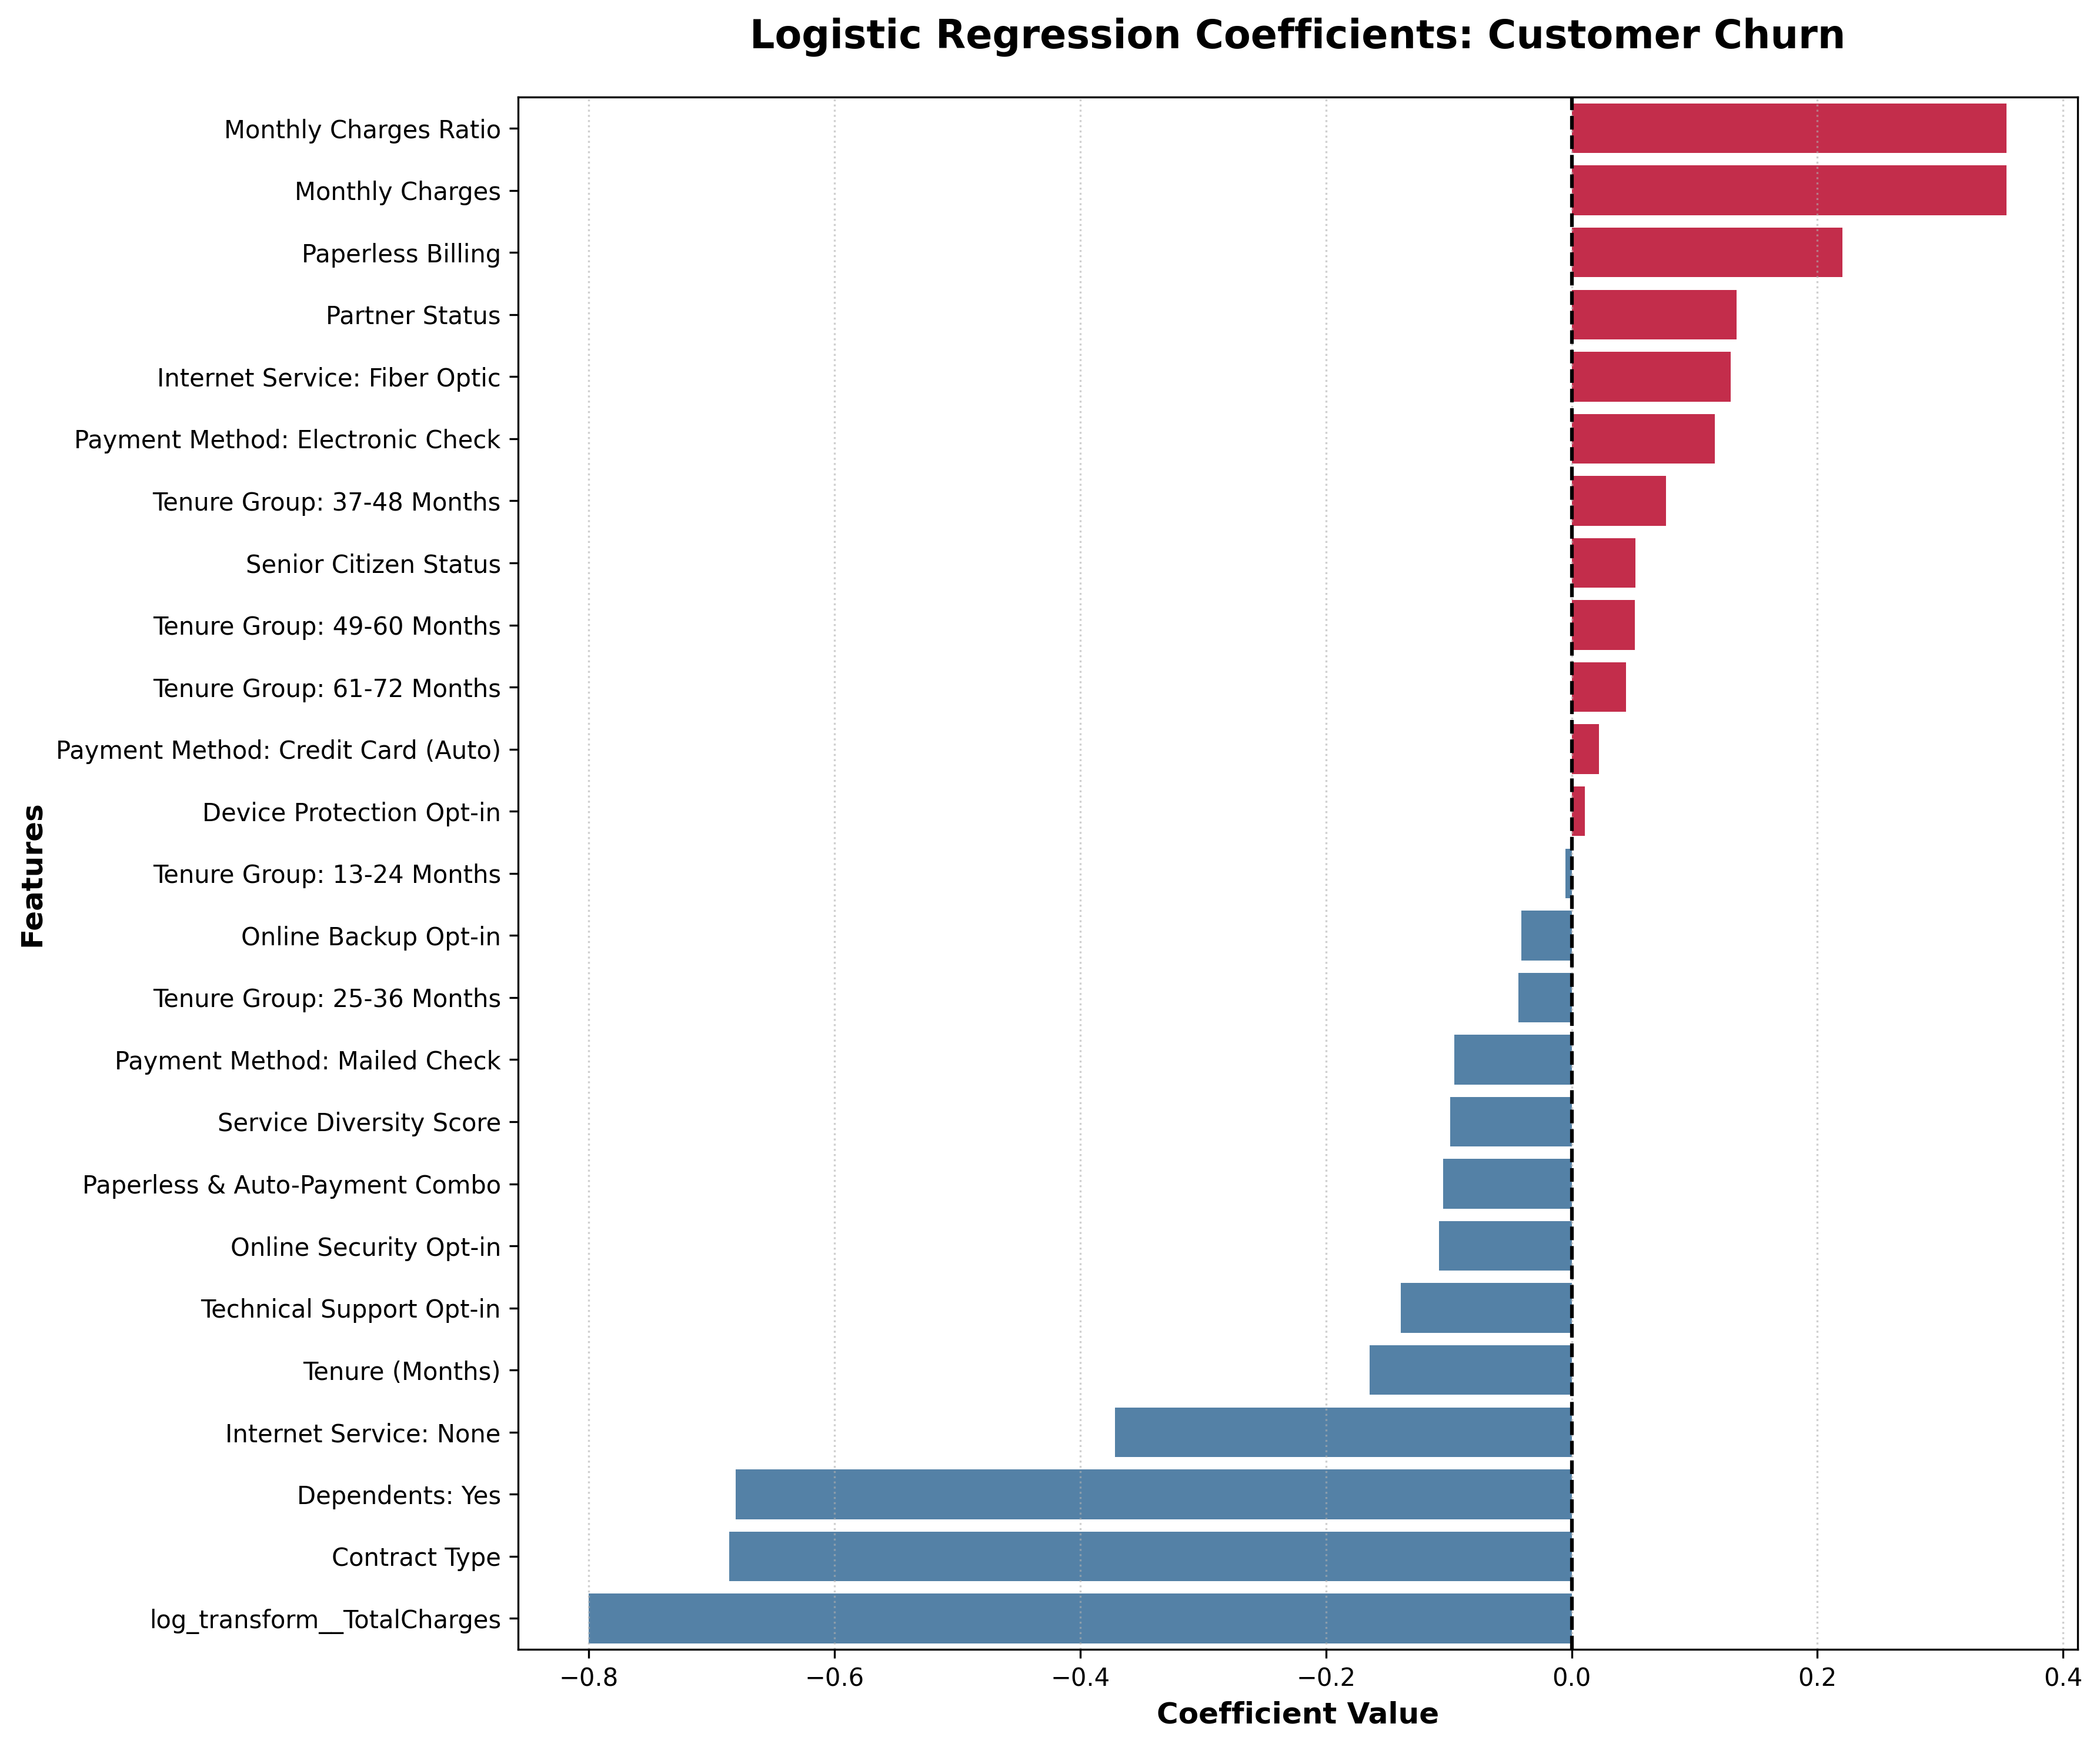

✅ [DONE] Biểu đồ Coefficients 
✅ [DONE] Biểu đồ Coefficients đã được tạo thành công.
TOP 10 FEATURES INCREASING CHURN RISK (POSITIVE COEFFICIENTS):
----------------------------------------------------------------------
                         Feature  Coefficient
           Monthly Charges Ratio       0.3540
                 Monthly Charges       0.3540
               Paperless Billing       0.2203
                  Partner Status       0.1345
   Internet Service: Fiber Optic       0.1296
Payment Method: Electronic Check       0.1163
      Tenure Group: 37-48 Months       0.0770
           Senior Citizen Status       0.0521
      Tenure Group: 49-60 Months       0.0517
      Tenure Group: 61-72 Months       0.0444
----------------------------------------------------------------------

TOP 10 FEATURES DECREASING CHURN RISK (NEGATIVE COEFFICIENTS):
----------------------------------------------------------------------
                       Feature  Coefficient
  Payment Method: Mailed 

In [ ]:
# ==========================================
# 5. TRỰC QUAN HÓA HỆ SỐ HỒI QUY (COEFFICIENTS)
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Trích xuất tên biến và trọng số từ mô hình
feature_names = X_train.columns
coefficients = log_reg_model.coef_[0]

# 2. Đưa vào DataFrame
coef_df = pd.DataFrame({
    'Feature_Raw': feature_names,
    'Coefficient': coefficients
})

# ==========================================
# CUSTOM FEATURE MAPPING FOR ACADEMIC REPORTING
# ==========================================

# ==========================================
# CUSTOM FEATURE MAPPING FOR ACADEMIC REPORTING
# ==========================================

# 1. Dùng Regex để xóa triệt để tiền tố Pipeline sinh ra
coef_df['Feature_Clean'] = coef_df['Feature_Raw'].str.replace(
    r'^(encoder__|remainder__|iqr_capper__)', '', regex=True
).str.strip()

# 2. Bảng từ điển map TOÀN BỘ 25 cột (đã bao gồm các cột do OneHotEncoder sinh ra)
custom_names = {
    # Nhóm biến sinh ra từ One-Hot Encoding
    'Dependents_Yes': 'Dependents: Yes',
    'PaymentMethod_Credit card (automatic)': 'Payment Method: Credit Card (Auto)',
    'PaymentMethod_Electronic check': 'Payment Method: Electronic Check',
    'PaymentMethod_Mailed check': 'Payment Method: Mailed Check',
    'InternetService_Fiber optic': 'Internet Service: Fiber Optic',
    'InternetService_No': 'Internet Service: None',
    'tenure_group_13-24 months': 'Tenure Group: 13-24 Months',
    'tenure_group_25-36 months': 'Tenure Group: 25-36 Months',
    'tenure_group_37-48 months': 'Tenure Group: 37-48 Months',
    'tenure_group_49-60 months': 'Tenure Group: 49-60 Months',
    'tenure_group_61-72 months': 'Tenure Group: 61-72 Months',
    
    # Nhóm biến số / Nhị phân giữ nguyên (Remainder)
    'SeniorCitizen': 'Senior Citizen Status',
    'Partner': 'Partner Status',
    'Tenure': 'Tenure (Months)',
    'Contract': 'Contract Type',
    'PaperlessBilling': 'Paperless Billing',
    'MonthlyCharges': 'Monthly Charges',
    'TotalCharges': 'Total Charges',
    'OnlineSecurity': 'Online Security Opt-in',
    'OnlineBackup': 'Online Backup Opt-in',
    'DeviceProtection': 'Device Protection Opt-in',
    'TechSupport': 'Technical Support Opt-in',
    
    # Nhóm Feature Engineering do Bảo tạo
    'service_diversity': 'Service Diversity Score',
    'monthly_charges_ratio': 'Monthly Charges Ratio',
    'is_paperless_electronic': 'Paperless & Auto-Payment Combo'
}

# 3. Áp dụng Mapping
coef_df['Feature_Clean'] = coef_df['Feature_Clean'].map(custom_names).fillna(coef_df['Feature_Clean'])

# 6. Sắp xếp trọng số giảm dần để trực quan hóa
coef_df = coef_df.sort_values(by='Coefficient', ascending=False)

# ==========================================
# VẼ BIỂU ĐỒ (ACADEMIC STYLE)
# ==========================================
plt.figure(figsize=(12, 10), dpi=300)

# Phân loại màu sắc: Dương (Đỏ - Tăng nguy cơ Churn), Âm (Xanh - Giữ chân khách hàng)
colors = np.where(coef_df['Coefficient'] > 0, 'crimson', 'steelblue')

sns.barplot(
    x='Coefficient', 
    y='Feature_Clean', 
    data=coef_df, 
    palette=colors.tolist()
)

# Cấu hình thẩm mỹ
plt.title('Logistic Regression Coefficients: Customer Churn', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Coefficient Value', fontsize=12, fontweight='bold')
plt.ylabel('Features', fontsize=12, fontweight='bold')

# Kẻ đường base-line tại mốc 0
plt.axvline(x=0, color='black', linestyle='--', linewidth=1.5)
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.tight_layout()

plt.show()

print(f"✅ [DONE] Biểu đồ Coefficients ")

print(f"✅ [DONE] Biểu đồ Coefficients đã được tạo thành công.")
print("=" * 70)

# Chọn đúng tên cột đang có trong DataFrame
cols_to_print = ["Feature_Clean", "Coefficient"]

# 1. In ra Top 10 biến làm TĂNG nguy cơ Churn (Hệ số Dương cao nhất)
print("TOP 10 FEATURES INCREASING CHURN RISK (POSITIVE COEFFICIENTS):")
print("-" * 70)
print(
    coef_df[cols_to_print]
    .head(10) # Lấy 10 dòng đầu tiên (do đã sort_values descending ở trên)
    .rename(columns={'Feature_Clean': 'Feature', 'Coefficient': 'Coefficient'}) # Đổi tên hiển thị cho đẹp
    .to_string(
        index=False, 
        float_format=lambda x: f"{x:.4f}" # Nên để 4 số thập phân để thấy rõ sự khác biệt của Log-Odds
    )
)
print("-" * 70)

# 2. (Bonus) In ra Top 10 biến làm GIẢM nguy cơ Churn (Hệ số Âm thấp nhất - Giữ chân khách hàng)
print("\nTOP 10 FEATURES DECREASING CHURN RISK (NEGATIVE COEFFICIENTS):")
print("-" * 70)
print(
    coef_df[cols_to_print]
    .tail(10) # Lấy 10 dòng cuối cùng
    .rename(columns={'Feature_Clean': 'Feature', 'Coefficient': 'Coefficient'})
    .to_string(
        index=False, 
        float_format=lambda x: f"{x:.4f}"
    )
)
print("=" * 70)